2025-11-19 11:59:09.002045: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763533749.021043  349704 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763533749.026855  349704 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763533749.042296  349704 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763533749.042312  349704 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763533749.042314  349704 computation_placer.cc:177] computation placer alr

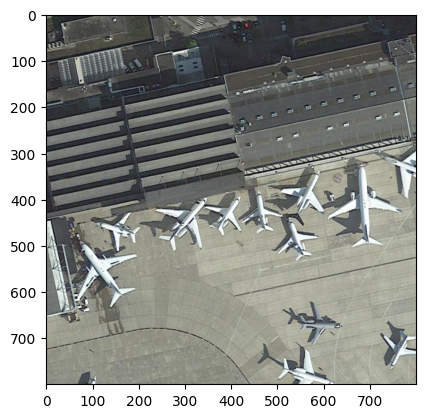

In [1]:
import io
import requests
import torch
import matplotlib.pyplot as plt
from PIL import Image
from transformers import DINOv3ViTConfig, DINOv3ViTModel

device = "cuda:1" if torch.cuda.is_available() else "cpu"
path = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/iclr_2026_processed_data/final_data/dota/processed/train/images/P2804_700_2100.png"

image = Image.open(path).convert("RGB")
plt.imshow(image)

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.48604..4.9230766].


Input image shape: torch.Size([1, 3, 512, 512])


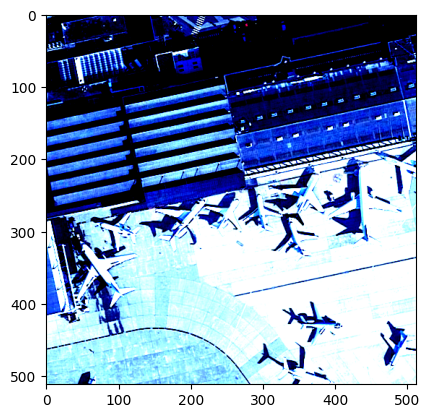

In [2]:
from transformers import AutoImageProcessor
processor = AutoImageProcessor.from_pretrained("facebook/dinov3-vitl16-pretrain-sat493m", use_fast=True, token=False)
model = DINOv3ViTModel.from_pretrained("facebook/dinov3-vitl16-pretrain-sat493m", token=False).to(device).eval()
img_size = 512
SAT_MEAN = [0.430, 0.411, 0.296]
SAT_STD  = [0.213, 0.156, 0.143]
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

processor.image_mean = SAT_MEAN
processor.image_std  = SAT_STD
inputs = processor(
    images=image,
    do_resize=True,
    size={"shortest_edge": img_size},
    do_center_crop=False,
    crop_size={"height": img_size, "width": img_size},
    return_tensors="pt",
)
hr_image = inputs["pixel_values"].to(device)

print("Input image shape:", hr_image.shape)
plt.imshow(hr_image[0].permute(1, 2, 0).cpu().numpy())


In [3]:
print("HF mean:", processor.image_mean)
print("HF std:", processor.image_std)

HF mean: [0.43, 0.411, 0.296]
HF std: [0.213, 0.156, 0.143]


In [4]:
with torch.no_grad():
    out = model(pixel_values=hr_image)
    all_tokens = out.last_hidden_state[:, 1:, :]  # drop [CLS]
    print("Token shape:", all_tokens.shape)
tokens_no_cls = all_tokens[:, 1:, :] 
print("Tokens without CLS shape:", tokens_no_cls.shape)
B, N_total, C = tokens_no_cls.shape
patch_size = model.config.patch_size
H, W = hr_image.shape[-2], hr_image.shape[-1]
print(f"Image size: {H}x{W}, Patch size: {patch_size}")
h = H // patch_size
w = W // patch_size
num_patches = h * w
print(f"Expected number of patches: {num_patches}, Tokens: {tokens_no_cls.shape[1]}")
patch_tokens = tokens_no_cls[:, :num_patches, :]
print("Patch tokens shape:", patch_tokens.shape)
lr_features = patch_tokens.reshape(B, h, w, C).permute(0, 3, 1, 2).contiguous()
print("LR feature map shape:", lr_features.shape)

Token shape: torch.Size([1, 1028, 1024])
Tokens without CLS shape: torch.Size([1, 1027, 1024])
Image size: 512x512, Patch size: 16
Expected number of patches: 1024, Tokens: 1027
Patch tokens shape: torch.Size([1, 1024, 1024])
LR feature map shape: torch.Size([1, 1024, 32, 32])


In [6]:
upsampler = torch.hub.load("wimmerth/anyup", "anyup", verbose=False).to(device).eval()
with torch.no_grad():
    # q_chunk_size can reduce memory if needed
    hr_features = upsampler(hr_image, lr_features, q_chunk_size=1024)  # (1, C, 448, 448)
    # hr_features = upsampler(hr_image, lr_features, vis_attn=True)

    print(hr_features.shape)

torch.Size([1, 1024, 512, 512])


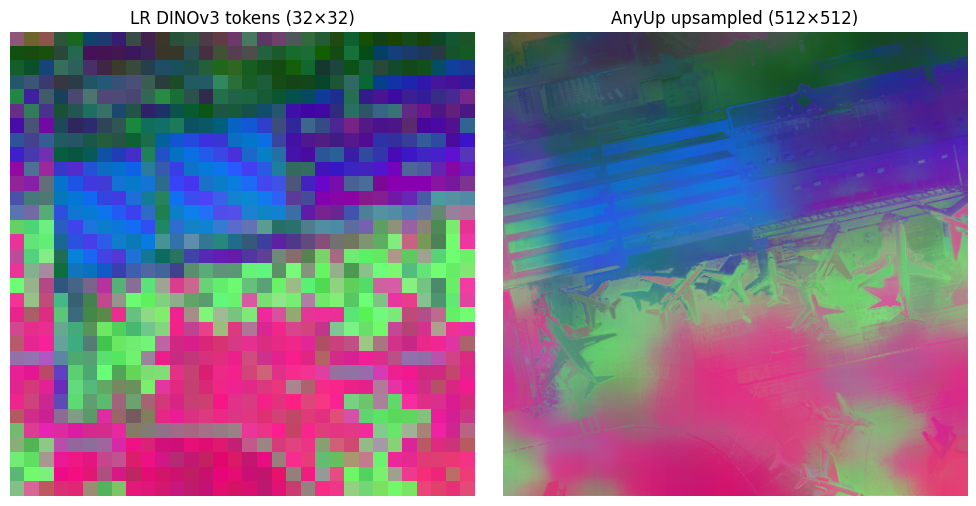

In [7]:
# 4) Joint PCA
with torch.no_grad():
    lr_flat = lr_features[0].permute(1, 2, 0).reshape(-1, C)
    hr_flat = hr_features[0].permute(1, 2, 0).reshape(-1, C)
    all_feats = torch.cat([lr_flat, hr_flat], dim=0)

    mean = all_feats.mean(dim=0, keepdim=True)
    X = all_feats - mean

    U, S, Vh = torch.linalg.svd(X, full_matrices=False)
    pcs = Vh[:3].T

    proj_all = X @ pcs

    # Split back and min-max normalize jointly for consistent coloring
    n_lr = h * w
    proj_lr = proj_all[:n_lr].reshape(h, w, 3)
    proj_hr = proj_all[n_lr:].reshape(img_size, img_size, 3)
    cmin = proj_all.min(dim=0).values
    cmax = proj_all.max(dim=0).values
    crng = (cmax - cmin).clamp(min=1e-6)

    lr_rgb = ((proj_lr - cmin) / crng).cpu().numpy()
    hr_rgb = ((proj_hr - cmin) / crng).cpu().numpy()

    # 5) Plot
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(lr_rgb)
    axs[0].set_title(f"LR DINOv3 tokens ({h}×{w})")
    axs[0].axis("off")
    axs[1].imshow(hr_rgb)
    axs[1].set_title(f"AnyUp upsampled ({img_size}×{img_size})")
    axs[1].axis("off")
    plt.tight_layout()
    plt.show()

In [8]:
# # After you have lr_features and hr_features
# B, C, h, w = lr_features.shape           # low-res grid size
# _, _, hr_h, hr_w = hr_features.shape     # high-res grid size (e.g. 50x50)

# with torch.no_grad():
#     # Flatten both for joint PCA
#     lr_flat = lr_features[0].permute(1, 2, 0).reshape(-1, C)    # [h*w, C]
#     hr_flat = hr_features[0].permute(1, 2, 0).reshape(-1, C)    # [hr_h*hr_w, C]
#     all_feats = torch.cat([lr_flat, hr_flat], dim=0)            # [(h*w + hr_h*hr_w), C]

#     # Center
#     mean = all_feats.mean(dim=0, keepdim=True)
#     X = all_feats - mean                                        # same shape

#     # SVD = PCA
#     U, S, Vh = torch.linalg.svd(X, full_matrices=False)
#     pcs = Vh[:3].T                                              # [C, 3]

#     # Project to 3D
#     proj_all = X @ pcs                                          # [(h*w + hr_h*hr_w), 3]

#     # Split back
#     n_lr = h * w
#     n_hr = hr_h * hr_w
#     assert proj_all.shape[0] == n_lr + n_hr

#     proj_lr = proj_all[:n_lr].reshape(h, w, 3)                  # [h, w, 3]
#     proj_hr = proj_all[n_lr:].reshape(hr_h, hr_w, 3)            # [hr_h, hr_w, 3]

#     # Joint min-max normalize for consistent coloring
#     cmin = proj_all.min(dim=0).values
#     cmax = proj_all.max(dim=0).values
#     crng = (cmax - cmin).clamp(min=1e-6)

#     lr_rgb = ((proj_lr - cmin) / crng).cpu().numpy()
#     hr_rgb = ((proj_hr - cmin) / crng).cpu().numpy()

#     # Plot
#     fig, axs = plt.subplots(1, 2, figsize=(10, 5))
#     axs[0].imshow(lr_rgb)
#     axs[0].set_title(f"LR tokens ({h}×{w})")
#     axs[0].axis("off")
#     axs[1].imshow(hr_rgb)
#     axs[1].set_title(f"AnyUp upsampled ({hr_h}×{hr_w})")
#     axs[1].axis("off")
#     plt.tight_layout()
#     plt.show()

In [9]:
import torch
import torch.nn as nn
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator

class AnyUpBackbone(nn.Module):
    def __init__(self, feature_extractor, in_channels=1024, out_channels=256):
        """
        feature_extractor(x) -> [B, in_channels, 512, 512]
        """
        super().__init__()
        self.feature_extractor = feature_extractor

        # 1x1 conv: 1024 -> 256 channels
        self.reduce = nn.Conv2d(in_channels, out_channels, kernel_size=1)

        # Downsample 512 -> 128 (stride 4) to make it usable for RPN/ROI
        self.down = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=4,
            stride=4,
            padding=0,
        )  # [B, 256, 128, 128]

        self.out_channels = out_channels  # required by FasterRCNN

    def forward(self, x):
        # x: [B,3,512,512]
        hr = self.feature_extractor(x)     # [B,1024,512,512]
        x = self.reduce(hr)                # [B,256,512,512]
        x = self.down(x)                   # [B,256,128,128]
        print("Backbone output shape:", x.shape)
        return {"0": x}                    # single feature map for FasterRCNN

In [ ]:
# feature_extractor is your DINO+AnyUp module wrapped to take images and return [B,1024,512,512]
backbone = AnyUpBackbone(feature_extractor=extract_anyup_features,
                         in_channels=1024,
                         out_channels=256)

anchor_generator = AnchorGenerator(
    sizes=((32, 64, 128, 256, 512),),
    aspect_ratios=((0.5, 1.0, 2.0),),
)

model = FasterRCNN(
    backbone=backbone,
    num_classes=num_classes,
    rpn_anchor_generator=anchor_generator,
)

In [29]:
from transformers import pipeline
from transformers.image_utils import load_image

# url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/pipeline-cat-chonk.jpeg"
# image = load_image(url)

feature_extractor = pipeline(
    model="facebook/dinov3-vitl16-pretrain-sat493m",
    task="image-feature-extraction", 
)
features = feature_extractor(image)
features_tensor = torch.tensor(features)
print("Feature tensor shape:", features_tensor.shape)

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Device set to use cuda:0


Feature tensor shape: torch.Size([1, 201, 1024])


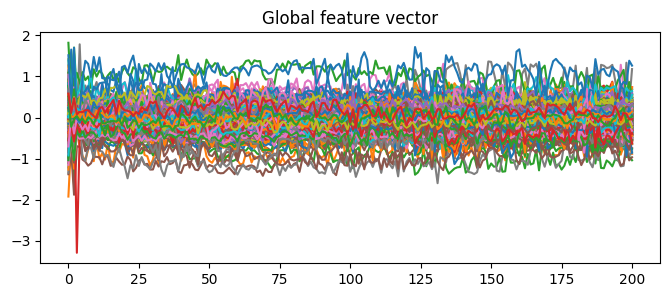

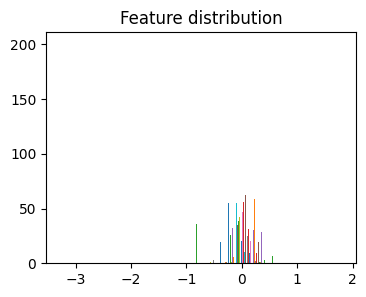

In [30]:
import matplotlib.pyplot as plt
import torch

features_tensor = torch.tensor(features)  # [1, D]
vec = features_tensor[0]

plt.figure(figsize=(8,3))
plt.plot(vec.numpy())
plt.title("Global feature vector")
plt.show()

plt.figure(figsize=(4,3))
plt.hist(vec.numpy(), bins=50)
plt.title("Feature distribution")
plt.show()

In [1]:
# import torch
# import matplotlib.pyplot as plt
# import numpy as np
# from PIL import Image
# from transformers import AutoImageProcessor, DINOv3ViTModel

# device = "cuda:1" if torch.cuda.is_available() else "cpu"

# # 1. Load image


# # 2. Processor + model (public DINOv3; sat493m is gated)
# model_name = "facebook/dinov3-vit7b16-pretrain-sat493m"
# processor = AutoImageProcessor.from_pretrained(model_name)
# model = DINOv3ViTModel.from_pretrained(model_name).to(device).eval()

# img_size = 512
# inputs = processor(
#     images=image,
#     do_resize=True,
#     size={"shortest_edge": img_size},
#     do_center_crop=True,
#     crop_size={"height": img_size, "width": img_size},
#     return_tensors="pt",
# )
# pixel_values = inputs["pixel_values"].to(device)   # [1,3,512,512]
# print("Input image shape:", pixel_values.shape)

# # 3. Forward
# with torch.no_grad():
#     out = model(pixel_values=pixel_values)
#     all_tokens = out.last_hidden_state     # [B, 1 + n_reg + n_patches, C]

# B, T, C = all_tokens.shape
# print("Token tensor shape:", all_tokens.shape)

# # 4. Drop CLS, then separate patch tokens from register tokens
# tokens_no_cls = all_tokens[:, 1:, :]      # [B, n_reg + n_patches, C]

# patch_size = model.config.patch_size      # 16 for vitl16
# H, W = pixel_values.shape[-2:]
# h = H // patch_size                       # 512/16 = 32
# w = W // patch_size                       # 32
# num_patches = h * w                       # 1024

# patch_tokens = tokens_no_cls[:, :num_patches, :]   # drop last 4 register tokens

# # 5. Reshape [B, N, C] -> [B, C, h, w]
# feat_map = patch_tokens.reshape(B, h, w, C).permute(0, 3, 1, 2).contiguous()
# print("Feature map shape:", feat_map.shape)   # [1, C, 32, 32]


# # 6. PCA to 3 channels
# fm = feat_map[0].permute(1, 2, 0).cpu().numpy()    # [32,32,C]
# Hf, Wf, Cf = fm.shape
# X = fm.reshape(-1, Cf)

# # simple PCA via SVD
# X_centered = X - X.mean(axis=0, keepdims=True)
# U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
# pcs = Vt[:3].T          # [C,3]
# proj = X_centered @ pcs # [N,3]
# proj = proj.reshape(Hf, Wf, 3)

# # normalize to [0,1]
# pmin = proj.min(axis=(0,1), keepdims=True)
# pmax = proj.max(axis=(0,1), keepdims=True)
# proj_norm = (proj - pmin) / (pmax - pmin + 1e-6)

# plt.figure(figsize=(4,4))
# plt.imshow(proj_norm)
# plt.axis("off")
# plt.title("DINOv3 ViT-L/16 feature map (PCA)")
# plt.show()